In [90]:
#1-BOSQICH. FAYLLARNI YIG'ISH (glob)

# Natijada 12 oy uchun bitta yagona "yillik savdo" jadvali hosil bo'lishi kerak.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob

from matplotlib.sphinxext.figmpl_directive import visit_figmpl_latex
from pandas import pivot_table

# a) glob yordamida "Savdo_2025_*.xlsx" naqshiga mos barcha 12 faylni avtomatik top.
fayllar = glob.glob("Savdo_2025_*.xlsx")
print(len(fayllar))


12


In [91]:
# b)Har bir faylni navbat bilan o'qib, bitta umumiy jadvalga (DataFrame) birlashtir (concat). Har bir qatorga qaysi oydan kelgani aniq bo'lishi kerak.

df = pd.concat([pd.read_excel(fayl) for fayl in fayllar])
df['oy'] = df['Sana_vaqt'].dt.month
df.shape

(8418, 11)

In [92]:
df

,Tranzaksiya_ID,Sana_vaqt,Filial_ID,Filial,Mahsulot_turkumi,Mahsulot_nomi,Miqdor,Narx_dona,Chegirma_foiz,Tolov_turi,oy
0,202501-00048,2025-01-03 16:41:00,F001,TOSHKENT CHILONZOR FILIALI,Konserva mahsulotlari,Qo'ziqorin konservasi,11,102000 so'm,0,KARTA,1
1,202501-00536,2025-01-16 16:23:00,F005,Andijon,Yog'-moy mahsulotlari,Margarin 400g,10,22000so'm,0,uzcard,1
2,202501-00404,2025-01-06 11:14:00,F006,farg'ona,Yog'-moy mahsulotlari,Sariyog' 500g,8,43000,0,Naqd,1
3,202501-00480,2025-01-12 12:15:00,F002,Yunusobod,NON MAHSULOTLARI,Lepyoshka,4,"41,000 so'm",0,Uzcard,1
4,202501-00176,2025-01-14 08:01:00,F008,Nukus,Non mahsulotlari,Oq non,9,149000 so'm,0,Click,1
...,...,...,...,...,...,...,...,...,...,...,...
630,202512-00364,2025-12-14 17:22:00,F002,toshkent yunusobod,Non mahsulotlari,Lepyoshka,2,199000 so'm,0,NAQD,12
631,202512-00125,2025-12-08 13:25:00,F004,buxoro,Ichimliklar,Choy 100g,2,123000so'm,0,KARTA,12
632,202512-00363,2025-12-17 20:25:00,F009,qarshi,Non mahsulotlari,Lepyoshka,9,16000,0,Karta,12
633,202512-00558,2025-12-23 21:23:00,F008,NUKUS FILIALI,Baliq mahsulotlari,Sim baliq 1kg,8,79000,0,KARTA,12


In [93]:
#c)Natijada 12 oy uchun bitta yagona "yillik savdo" jadvali hosil bo'lishi kerak.

df.duplicated().sum()
df = df.drop_duplicates()

In [94]:
df.duplicated().sum()
df

,Tranzaksiya_ID,Sana_vaqt,Filial_ID,Filial,Mahsulot_turkumi,Mahsulot_nomi,Miqdor,Narx_dona,Chegirma_foiz,Tolov_turi,oy
0,202501-00048,2025-01-03 16:41:00,F001,TOSHKENT CHILONZOR FILIALI,Konserva mahsulotlari,Qo'ziqorin konservasi,11,102000 so'm,0,KARTA,1
1,202501-00536,2025-01-16 16:23:00,F005,Andijon,Yog'-moy mahsulotlari,Margarin 400g,10,22000so'm,0,uzcard,1
2,202501-00404,2025-01-06 11:14:00,F006,farg'ona,Yog'-moy mahsulotlari,Sariyog' 500g,8,43000,0,Naqd,1
3,202501-00480,2025-01-12 12:15:00,F002,Yunusobod,NON MAHSULOTLARI,Lepyoshka,4,"41,000 so'm",0,Uzcard,1
4,202501-00176,2025-01-14 08:01:00,F008,Nukus,Non mahsulotlari,Oq non,9,149000 so'm,0,Click,1
...,...,...,...,...,...,...,...,...,...,...,...
630,202512-00364,2025-12-14 17:22:00,F002,toshkent yunusobod,Non mahsulotlari,Lepyoshka,2,199000 so'm,0,NAQD,12
631,202512-00125,2025-12-08 13:25:00,F004,buxoro,Ichimliklar,Choy 100g,2,123000so'm,0,KARTA,12
632,202512-00363,2025-12-17 20:25:00,F009,qarshi,Non mahsulotlari,Lepyoshka,9,16000,0,Karta,12
633,202512-00558,2025-12-23 21:23:00,F008,NUKUS FILIALI,Baliq mahsulotlari,Sim baliq 1kg,8,79000,0,KARTA,12


In [95]:
#2-BOSQICH. MATNLARNI TOZALASH (str: lower/upper/strip/replace)

# a) "Filial" ustuni juda xilma-xil yozilgan (katta-kichik harflar, bo'sh joylar, qisqartmalar: masalan "TOSHKENT CHILONZOR FILIALI", "chilonzor", " Toshkent Chilonzor "). Bu ustunni tozalab, har bir filial uchun BITTA standart nomga keltir (kichik harf, bo'sh joylarni olib tashlash, keraksiz so'zlarni almashtirish/o'chirish).

df['Filial'] = df['Filial'].str.strip()
df['Filial'] = df['Filial'].apply(
    lambda text: ' '.join(
        word.lower() if word.lower() in ['filial', 'filiali'] else word.capitalize()
        for word in str(text).split()
    )
)

df['Filial'] = df['Filial'].str.replace('filiali', '', regex=False)
df['Filial'] = df['Filial'].str.replace('markaziy', '', regex=False)
df['Filial'] = df['Filial'].str.replace('filial', '', regex=False)

df['Filial'] = df['Filial'].str.strip()
df


,Tranzaksiya_ID,Sana_vaqt,Filial_ID,Filial,Mahsulot_turkumi,Mahsulot_nomi,Miqdor,Narx_dona,Chegirma_foiz,Tolov_turi,oy
0,202501-00048,2025-01-03 16:41:00,F001,Toshkent Chilonzor,Konserva mahsulotlari,Qo'ziqorin konservasi,11,102000 so'm,0,KARTA,1
1,202501-00536,2025-01-16 16:23:00,F005,Andijon,Yog'-moy mahsulotlari,Margarin 400g,10,22000so'm,0,uzcard,1
2,202501-00404,2025-01-06 11:14:00,F006,Farg'ona,Yog'-moy mahsulotlari,Sariyog' 500g,8,43000,0,Naqd,1
3,202501-00480,2025-01-12 12:15:00,F002,Yunusobod,NON MAHSULOTLARI,Lepyoshka,4,"41,000 so'm",0,Uzcard,1
4,202501-00176,2025-01-14 08:01:00,F008,Nukus,Non mahsulotlari,Oq non,9,149000 so'm,0,Click,1
...,...,...,...,...,...,...,...,...,...,...,...
630,202512-00364,2025-12-14 17:22:00,F002,Toshkent Yunusobod,Non mahsulotlari,Lepyoshka,2,199000 so'm,0,NAQD,12
631,202512-00125,2025-12-08 13:25:00,F004,Buxoro,Ichimliklar,Choy 100g,2,123000so'm,0,KARTA,12
632,202512-00363,2025-12-17 20:25:00,F009,Qarshi,Non mahsulotlari,Lepyoshka,9,16000,0,Karta,12
633,202512-00558,2025-12-23 21:23:00,F008,Nukus,Baliq mahsulotlari,Sim baliq 1kg,8,79000,0,KARTA,12


In [96]:

# b) "Mahsulot_turkumi" ustunida ba'zi qiymatlar butunlay KATTA HARFLARDA — buni ham bitta formatga keltir.

df['Mahsulot_turkumi'] = df['Mahsulot_turkumi'].str.strip()
df['Mahsulot_turkumi'] = df['Mahsulot_turkumi'].str.capitalize()
df



,Tranzaksiya_ID,Sana_vaqt,Filial_ID,Filial,Mahsulot_turkumi,Mahsulot_nomi,Miqdor,Narx_dona,Chegirma_foiz,Tolov_turi,oy
0,202501-00048,2025-01-03 16:41:00,F001,Toshkent Chilonzor,Konserva mahsulotlari,Qo'ziqorin konservasi,11,102000 so'm,0,KARTA,1
1,202501-00536,2025-01-16 16:23:00,F005,Andijon,Yog'-moy mahsulotlari,Margarin 400g,10,22000so'm,0,uzcard,1
2,202501-00404,2025-01-06 11:14:00,F006,Farg'ona,Yog'-moy mahsulotlari,Sariyog' 500g,8,43000,0,Naqd,1
3,202501-00480,2025-01-12 12:15:00,F002,Yunusobod,Non mahsulotlari,Lepyoshka,4,"41,000 so'm",0,Uzcard,1
4,202501-00176,2025-01-14 08:01:00,F008,Nukus,Non mahsulotlari,Oq non,9,149000 so'm,0,Click,1
...,...,...,...,...,...,...,...,...,...,...,...
630,202512-00364,2025-12-14 17:22:00,F002,Toshkent Yunusobod,Non mahsulotlari,Lepyoshka,2,199000 so'm,0,NAQD,12
631,202512-00125,2025-12-08 13:25:00,F004,Buxoro,Ichimliklar,Choy 100g,2,123000so'm,0,KARTA,12
632,202512-00363,2025-12-17 20:25:00,F009,Qarshi,Non mahsulotlari,Lepyoshka,9,16000,0,Karta,12
633,202512-00558,2025-12-23 21:23:00,F008,Nukus,Baliq mahsulotlari,Sim baliq 1kg,8,79000,0,KARTA,12


In [97]:
# c) "Tolov_turi" ustunida ham xil xillik bor (Naqd/naqd/NAQD va h.k.) — bitta standartga keltir.

df['Tolov_turi'] = df['Tolov_turi'].str.strip()
df['Tolov_turi'] = df['Tolov_turi'].str.lower()
df

,Tranzaksiya_ID,Sana_vaqt,Filial_ID,Filial,Mahsulot_turkumi,Mahsulot_nomi,Miqdor,Narx_dona,Chegirma_foiz,Tolov_turi,oy
0,202501-00048,2025-01-03 16:41:00,F001,Toshkent Chilonzor,Konserva mahsulotlari,Qo'ziqorin konservasi,11,102000 so'm,0,karta,1
1,202501-00536,2025-01-16 16:23:00,F005,Andijon,Yog'-moy mahsulotlari,Margarin 400g,10,22000so'm,0,uzcard,1
2,202501-00404,2025-01-06 11:14:00,F006,Farg'ona,Yog'-moy mahsulotlari,Sariyog' 500g,8,43000,0,naqd,1
3,202501-00480,2025-01-12 12:15:00,F002,Yunusobod,Non mahsulotlari,Lepyoshka,4,"41,000 so'm",0,uzcard,1
4,202501-00176,2025-01-14 08:01:00,F008,Nukus,Non mahsulotlari,Oq non,9,149000 so'm,0,click,1
...,...,...,...,...,...,...,...,...,...,...,...
630,202512-00364,2025-12-14 17:22:00,F002,Toshkent Yunusobod,Non mahsulotlari,Lepyoshka,2,199000 so'm,0,naqd,12
631,202512-00125,2025-12-08 13:25:00,F004,Buxoro,Ichimliklar,Choy 100g,2,123000so'm,0,karta,12
632,202512-00363,2025-12-17 20:25:00,F009,Qarshi,Non mahsulotlari,Lepyoshka,9,16000,0,karta,12
633,202512-00558,2025-12-23 21:23:00,F008,Nukus,Baliq mahsulotlari,Sim baliq 1kg,8,79000,0,karta,12


In [99]:
# d) "Miqdor" ustunida ba'zi qiymatlar "5 dona" kabi matn ko'rinishida — sondan boshqa harflarni olib tashlab, faqat raqamni qoldir.

# 3-bosqich
# a)Tozalangan "Narx_dona" va "Miqdor" ustunlarini son turiga (int yoki float) o'tkaz (astype).

df['Miqdor'] = df['Miqdor'].astype(str).str.replace(r'\D', '', regex=True)
df['Miqdor'] = pd.to_numeric(df['Miqdor'], errors='coerce')
df['Miqdor'] = df['Miqdor'].fillna(0)
df['Miqdor'].unique()

df['Miqdor'] = df['Miqdor'].astype(str).str.replace(r'\D', '', regex=True)
df['Miqdor'] = df['Miqdor'].replace('', '0')
df['Miqdor'] = df['Miqdor'].astype(int)
print(df['Miqdor'].dtype)  # int64 chiqishi kerak


int64
int64


In [101]:
df

,Tranzaksiya_ID,Sana_vaqt,Filial_ID,Filial,Mahsulot_turkumi,Mahsulot_nomi,Miqdor,Narx_dona,Chegirma_foiz,Tolov_turi,oy
0,202501-00048,2025-01-03 16:41:00,F001,Toshkent Chilonzor,Konserva mahsulotlari,Qo'ziqorin konservasi,11,102000 so'm,0,karta,1
1,202501-00536,2025-01-16 16:23:00,F005,Andijon,Yog'-moy mahsulotlari,Margarin 400g,10,22000so'm,0,uzcard,1
2,202501-00404,2025-01-06 11:14:00,F006,Farg'ona,Yog'-moy mahsulotlari,Sariyog' 500g,8,43000,0,naqd,1
3,202501-00480,2025-01-12 12:15:00,F002,Yunusobod,Non mahsulotlari,Lepyoshka,4,"41,000 so'm",0,uzcard,1
4,202501-00176,2025-01-14 08:01:00,F008,Nukus,Non mahsulotlari,Oq non,9,149000 so'm,0,click,1
...,...,...,...,...,...,...,...,...,...,...,...
630,202512-00364,2025-12-14 17:22:00,F002,Toshkent Yunusobod,Non mahsulotlari,Lepyoshka,2,199000 so'm,0,naqd,12
631,202512-00125,2025-12-08 13:25:00,F004,Buxoro,Ichimliklar,Choy 100g,2,123000so'm,0,karta,12
632,202512-00363,2025-12-17 20:25:00,F009,Qarshi,Non mahsulotlari,Lepyoshka,9,16000,0,karta,12
633,202512-00558,2025-12-23 21:23:00,F008,Nukus,Baliq mahsulotlari,Sim baliq 1kg,8,79000,0,karta,12


,Tranzaksiya_ID,Sana_vaqt,Filial_ID,Filial,Mahsulot_turkumi,Mahsulot_nomi,Miqdor,Narx_dona,Chegirma_foiz,Tolov_turi,oy
0,202501-00048,2025-01-03 16:41:00,F001,Toshkent Chilonzor,Konserva mahsulotlari,Qo'ziqorin konservasi,11,102000 so'm,0,karta,1
1,202501-00536,2025-01-16 16:23:00,F005,Andijon,Yog'-moy mahsulotlari,Margarin 400g,10,22000so'm,0,uzcard,1
2,202501-00404,2025-01-06 11:14:00,F006,Farg'ona,Yog'-moy mahsulotlari,Sariyog' 500g,8,43000,0,naqd,1
3,202501-00480,2025-01-12 12:15:00,F002,Yunusobod,Non mahsulotlari,Lepyoshka,4,"41,000 so'm",0,uzcard,1
4,202501-00176,2025-01-14 08:01:00,F008,Nukus,Non mahsulotlari,Oq non,9,149000 so'm,0,click,1
...,...,...,...,...,...,...,...,...,...,...,...
630,202512-00364,2025-12-14 17:22:00,F002,Toshkent Yunusobod,Non mahsulotlari,Lepyoshka,2,199000 so'm,0,naqd,12
631,202512-00125,2025-12-08 13:25:00,F004,Buxoro,Ichimliklar,Choy 100g,2,123000so'm,0,karta,12
632,202512-00363,2025-12-17 20:25:00,F009,Qarshi,Non mahsulotlari,Lepyoshka,9,16000,0,karta,12
633,202512-00558,2025-12-23 21:23:00,F008,Nukus,Baliq mahsulotlari,Sim baliq 1kg,8,79000,0,karta,12


In [103]:
df.dtypes

Tranzaksiya_ID                 str
Sana_vaqt           datetime64[us]
Filial_ID                      str
Filial                         str
Mahsulot_turkumi               str
Mahsulot_nomi                  str
Miqdor                       int64
Narx_dona                      str
Chegirma_foiz                int64
Tolov_turi                     str
oy                           int32
dtype: object

Tranzaksiya_ID                 str
Sana_vaqt           datetime64[us]
Filial_ID                      str
Filial                         str
Mahsulot_turkumi               str
Mahsulot_nomi                  str
Miqdor                       int64
Narx_dona                      str
Chegirma_foiz                int64
Tolov_turi                     str
oy                           int32
dtype: object

In [105]:
df.isna().sum()

Tranzaksiya_ID        0
Sana_vaqt             0
Filial_ID             0
Filial                0
Mahsulot_turkumi      0
Mahsulot_nomi         0
Miqdor                0
Narx_dona           395
Chegirma_foiz         0
Tolov_turi            0
oy                    0
dtype: int64

Tranzaksiya_ID        0
Sana_vaqt             0
Filial_ID             0
Filial                0
Mahsulot_turkumi      0
Mahsulot_nomi         0
Miqdor                0
Narx_dona           395
Chegirma_foiz         0
Tolov_turi            0
oy                    0
dtype: int64

In [107]:
# e) "Narx_dona" ustuni eng "iflos" ustun: unda "15000", "15,000 so'm", "15000so'm", " 15000 " kabi turli formatlar bor, ba'zi qiymatlar bo'sh (NaN). Buni tozalab faqat raqam qoldirishga harakat qil.

# 3-bosqich
# a)Tozalangan "Narx_dona" va "Miqdor" ustunlarini son turiga (int yoki float) o'tkaz (astype).

import numpy as np

df["Narx_dona"] = (
    df["Narx_dona"]
    .astype(str)
    .str.lower()
    .str.replace("so'm", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
df.loc[df["Narx_dona"].isin(["nan", ""]), "Narx_dona"] = np.nan

df["Narx_dona"] = df["Narx_dona"].astype(float)
mediana_narx = df["Narx_dona"].median()
df["Narx_dona"] = df["Narx_dona"].fillna(mediana_narx)
df["Narx_dona"] = df["Narx_dona"].astype(int)
print(df["Narx_dona"].dtype)  # int64 chiqadi
print(df["Narx_dona"].isna().sum())


int64
0
int64
0


In [109]:
#3-bosqich
# b)"Chegirma_foiz" ustunini ham son turida ekanligini tekshir.

df.dtypes


Tranzaksiya_ID                 str
Sana_vaqt           datetime64[us]
Filial_ID                      str
Filial                         str
Mahsulot_turkumi               str
Mahsulot_nomi                  str
Miqdor                       int64
Narx_dona                    int64
Chegirma_foiz                int64
Tolov_turi                     str
oy                           int32
dtype: object

Tranzaksiya_ID                 str
Sana_vaqt           datetime64[us]
Filial_ID                      str
Filial                         str
Mahsulot_turkumi               str
Mahsulot_nomi                  str
Miqdor                       int64
Narx_dona                    int64
Chegirma_foiz                int64
Tolov_turi                     str
oy                           int32
dtype: object

In [111]:
df['Jami_summa'] = df['Narx_dona'] * df['Miqdor'] * (1 - df['Chegirma_foiz']/100)
df['Jami_summa'] = df['Jami_summa'].astype(int)
df

,Tranzaksiya_ID,Sana_vaqt,Filial_ID,Filial,Mahsulot_turkumi,Mahsulot_nomi,Miqdor,Narx_dona,Chegirma_foiz,Tolov_turi,oy,Jami_summa
0,202501-00048,2025-01-03 16:41:00,F001,Toshkent Chilonzor,Konserva mahsulotlari,Qo'ziqorin konservasi,11,102000,0,karta,1,1122000
1,202501-00536,2025-01-16 16:23:00,F005,Andijon,Yog'-moy mahsulotlari,Margarin 400g,10,22000,0,uzcard,1,220000
2,202501-00404,2025-01-06 11:14:00,F006,Farg'ona,Yog'-moy mahsulotlari,Sariyog' 500g,8,43000,0,naqd,1,344000
3,202501-00480,2025-01-12 12:15:00,F002,Yunusobod,Non mahsulotlari,Lepyoshka,4,41000,0,uzcard,1,164000
4,202501-00176,2025-01-14 08:01:00,F008,Nukus,Non mahsulotlari,Oq non,9,149000,0,click,1,1341000
...,...,...,...,...,...,...,...,...,...,...,...,...
630,202512-00364,2025-12-14 17:22:00,F002,Toshkent Yunusobod,Non mahsulotlari,Lepyoshka,2,199000,0,naqd,12,398000
631,202512-00125,2025-12-08 13:25:00,F004,Buxoro,Ichimliklar,Choy 100g,2,123000,0,karta,12,246000
632,202512-00363,2025-12-17 20:25:00,F009,Qarshi,Non mahsulotlari,Lepyoshka,9,16000,0,karta,12,144000
633,202512-00558,2025-12-23 21:23:00,F008,Nukus,Baliq mahsulotlari,Sim baliq 1kg,8,79000,0,karta,12,632000


,Tranzaksiya_ID,Sana_vaqt,Filial_ID,Filial,Mahsulot_turkumi,Mahsulot_nomi,Miqdor,Narx_dona,Chegirma_foiz,Tolov_turi,oy,Jami_summa
0,202501-00048,2025-01-03 16:41:00,F001,Toshkent Chilonzor,Konserva mahsulotlari,Qo'ziqorin konservasi,11,102000,0,karta,1,1122000
1,202501-00536,2025-01-16 16:23:00,F005,Andijon,Yog'-moy mahsulotlari,Margarin 400g,10,22000,0,uzcard,1,220000
2,202501-00404,2025-01-06 11:14:00,F006,Farg'ona,Yog'-moy mahsulotlari,Sariyog' 500g,8,43000,0,naqd,1,344000
3,202501-00480,2025-01-12 12:15:00,F002,Yunusobod,Non mahsulotlari,Lepyoshka,4,41000,0,uzcard,1,164000
4,202501-00176,2025-01-14 08:01:00,F008,Nukus,Non mahsulotlari,Oq non,9,149000,0,click,1,1341000
...,...,...,...,...,...,...,...,...,...,...,...,...
630,202512-00364,2025-12-14 17:22:00,F002,Toshkent Yunusobod,Non mahsulotlari,Lepyoshka,2,199000,0,naqd,12,398000
631,202512-00125,2025-12-08 13:25:00,F004,Buxoro,Ichimliklar,Choy 100g,2,123000,0,karta,12,246000
632,202512-00363,2025-12-17 20:25:00,F009,Qarshi,Non mahsulotlari,Lepyoshka,9,16000,0,karta,12,144000
633,202512-00558,2025-12-23 21:23:00,F008,Nukus,Baliq mahsulotlari,Sim baliq 1kg,8,79000,0,karta,12,632000


In [113]:
#4-BOSQICH. SANA VA VAQT (dt.month, tz)
# a)"Sana_vaqt" ustunini datetime turiga o'tkaz.

df['Sana_vaqt'] = pd.to_datetime(df['Sana_vaqt'])
df['Sana_vaqt']

# b) Undan "Oy" (dt.month), "Kun" (dt.day) va "Hafta_kuni" (dt.day_name()) ustunlarini ajratib chiqar.
df['Kun'] = df['Sana_vaqt'].dt.day
df['Hafta_kuni'] = df['Sana_vaqt'].dt.day_name()

hafta_kunlari= {
    'Monday': 'Dushanba',
    'Tuesday': 'Seshanba',
    'Wednesday': 'Chorshanba',
    'Thursday': 'Payshanba',
    'Friday': 'Juma',
    'Saturday': 'Shanba',
    'Sunday': 'Yakshanba',
}

# 2. dt.day_name() dan keyin map bilan o'zbekchaga o'giramiz
df['Hafta_kuni'] = df['Sana_vaqt'].dt.day_name().map(hafta_kunlari)
df

,Tranzaksiya_ID,Sana_vaqt,Filial_ID,Filial,Mahsulot_turkumi,Mahsulot_nomi,Miqdor,Narx_dona,Chegirma_foiz,Tolov_turi,oy,Jami_summa,Kun,Hafta_kuni
0,202501-00048,2025-01-03 16:41:00,F001,Toshkent Chilonzor,Konserva mahsulotlari,Qo'ziqorin konservasi,11,102000,0,karta,1,1122000,3,Juma
1,202501-00536,2025-01-16 16:23:00,F005,Andijon,Yog'-moy mahsulotlari,Margarin 400g,10,22000,0,uzcard,1,220000,16,Payshanba
2,202501-00404,2025-01-06 11:14:00,F006,Farg'ona,Yog'-moy mahsulotlari,Sariyog' 500g,8,43000,0,naqd,1,344000,6,Dushanba
3,202501-00480,2025-01-12 12:15:00,F002,Yunusobod,Non mahsulotlari,Lepyoshka,4,41000,0,uzcard,1,164000,12,Yakshanba
4,202501-00176,2025-01-14 08:01:00,F008,Nukus,Non mahsulotlari,Oq non,9,149000,0,click,1,1341000,14,Seshanba
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
630,202512-00364,2025-12-14 17:22:00,F002,Toshkent Yunusobod,Non mahsulotlari,Lepyoshka,2,199000,0,naqd,12,398000,14,Yakshanba
631,202512-00125,2025-12-08 13:25:00,F004,Buxoro,Ichimliklar,Choy 100g,2,123000,0,karta,12,246000,8,Dushanba
632,202512-00363,2025-12-17 20:25:00,F009,Qarshi,Non mahsulotlari,Lepyoshka,9,16000,0,karta,12,144000,17,Chorshanba
633,202512-00558,2025-12-23 21:23:00,F008,Nukus,Baliq mahsulotlari,Sim baliq 1kg,8,79000,0,karta,12,632000,23,Seshanba


,Tranzaksiya_ID,Sana_vaqt,Filial_ID,Filial,Mahsulot_turkumi,Mahsulot_nomi,Miqdor,Narx_dona,Chegirma_foiz,Tolov_turi,oy,Jami_summa,Kun,Hafta_kuni
0,202501-00048,2025-01-03 16:41:00,F001,Toshkent Chilonzor,Konserva mahsulotlari,Qo'ziqorin konservasi,11,102000,0,karta,1,1122000,3,Juma
1,202501-00536,2025-01-16 16:23:00,F005,Andijon,Yog'-moy mahsulotlari,Margarin 400g,10,22000,0,uzcard,1,220000,16,Payshanba
2,202501-00404,2025-01-06 11:14:00,F006,Farg'ona,Yog'-moy mahsulotlari,Sariyog' 500g,8,43000,0,naqd,1,344000,6,Dushanba
3,202501-00480,2025-01-12 12:15:00,F002,Yunusobod,Non mahsulotlari,Lepyoshka,4,41000,0,uzcard,1,164000,12,Yakshanba
4,202501-00176,2025-01-14 08:01:00,F008,Nukus,Non mahsulotlari,Oq non,9,149000,0,click,1,1341000,14,Seshanba
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
630,202512-00364,2025-12-14 17:22:00,F002,Toshkent Yunusobod,Non mahsulotlari,Lepyoshka,2,199000,0,naqd,12,398000,14,Yakshanba
631,202512-00125,2025-12-08 13:25:00,F004,Buxoro,Ichimliklar,Choy 100g,2,123000,0,karta,12,246000,8,Dushanba
632,202512-00363,2025-12-17 20:25:00,F009,Qarshi,Non mahsulotlari,Lepyoshka,9,16000,0,karta,12,144000,17,Chorshanba
633,202512-00558,2025-12-23 21:23:00,F008,Nukus,Baliq mahsulotlari,Sim baliq 1kg,8,79000,0,karta,12,632000,23,Seshanba


In [115]:
# c) "Sana_vaqt" ustuniga "Asia/Tashkent" vaqt zonasini biriktir (tz_localize), so'ngra uni UTC vaqt zonasiga o'tkaz (tz_convert) va ikkisini solishtir.

df['Sana_Tashkent'] = df['Sana_vaqt'].dt.tz_localize('Asia/Tashkent')
df['Sana_UTC'] = df['Sana_Tashkent'].dt.tz_convert('UTC')
df[['Sana_vaqt', 'Sana_Tashkent', 'Sana_UTC']].head()

# d) Qaysi soatlarda (ish kuni davomida) eng ko'p sotuv bo'lishini top.

,Sana_vaqt,Sana_Tashkent,Sana_UTC
0,2025-01-03 16:41:00,2025-01-03 16:41:00+05:00,2025-01-03 11:41:00+00:00
1,2025-01-16 16:23:00,2025-01-16 16:23:00+05:00,2025-01-16 11:23:00+00:00
2,2025-01-06 11:14:00,2025-01-06 11:14:00+05:00,2025-01-06 06:14:00+00:00
3,2025-01-12 12:15:00,2025-01-12 12:15:00+05:00,2025-01-12 07:15:00+00:00
4,2025-01-14 08:01:00,2025-01-14 08:01:00+05:00,2025-01-14 03:01:00+00:00


,Sana_vaqt,Sana_Tashkent,Sana_UTC
0,2025-01-03 16:41:00,2025-01-03 16:41:00+05:00,2025-01-03 11:41:00+00:00
1,2025-01-16 16:23:00,2025-01-16 16:23:00+05:00,2025-01-16 11:23:00+00:00
2,2025-01-06 11:14:00,2025-01-06 11:14:00+05:00,2025-01-06 06:14:00+00:00
3,2025-01-12 12:15:00,2025-01-12 12:15:00+05:00,2025-01-12 07:15:00+00:00
4,2025-01-14 08:01:00,2025-01-14 08:01:00+05:00,2025-01-14 03:01:00+00:00


In [117]:
#5-BOSQICH. FILIALLAR BAZASI BILAN BIRLASHTIRISH (merge)
# a)Savdo jadvalida endi "Filial_ID" ustuni ham bor (masalan "F001", "F002"). Merge ANIQ va ISHONCHLI bo'lishi uchun matn ustuni ("Filial") emas, aynan shu "Filial_ID" ustunidan foydalanib 00_Filiallar_royhati.xlsx dagi "Filial_ID" ustuni bilan birlashtir (merge, left join, key=Filial_ID).
# b) Merge natijasida har bir savdo qatoriga: Filial_nomi (standart, toza nom), Viloyat, Shahar, Menejer_FISH, Xodimlar_soni ustunlari qo'shilishi kerak.

Filiallar = pd.read_excel("00_Filiallar_royhati.xlsx")
Filiallar
df = df.merge(Filiallar, how='left', on='Filial_ID')
df

,Tranzaksiya_ID,Sana_vaqt,Filial_ID,Filial,Mahsulot_turkumi,Mahsulot_nomi,Miqdor,Narx_dona,Chegirma_foiz,Tolov_turi,...,Sana_UTC,Filial_nomi,Shahar,Viloyat,Manzil,Ochilgan_sana,Menejer_FISH,Xodimlar_soni,Maydon_kvm,Telefon
0,202501-00048,2025-01-03 16:41:00,F001,Toshkent Chilonzor,Konserva mahsulotlari,Qo'ziqorin konservasi,11,102000,0,karta,...,2025-01-03 11:41:00+00:00,Toshkent Chilonzor filiali,Toshkent,Toshkent shahri,"Chilonzor tumani, Bunyodkor ko'chasi 12",2018-03-15,Aliyev Bekzod Aliyevich,34,1200,+998 71 200 11 01
1,202501-00536,2025-01-16 16:23:00,F005,Andijon,Yog'-moy mahsulotlari,Margarin 400g,10,22000,0,uzcard,...,2025-01-16 11:23:00+00:00,Andijon filiali,Andijon,Andijon viloyati,Bobur shoh ko'chasi 17,2019-11-05,Tursunov Sardor Ilhomovich,24,700,+998 74 223 12 09
2,202501-00404,2025-01-06 11:14:00,F006,Farg'ona,Yog'-moy mahsulotlari,Sariyog' 500g,8,43000,0,naqd,...,2025-01-06 06:14:00+00:00,Farg'ona filiali,Farg'ona,Farg'ona viloyati,Mustaqillik ko'chasi 22,2021-04-12,Nazarova Gulnoza Baxtiyorovna,19,600,+998 73 244 18 20
3,202501-00480,2025-01-12 12:15:00,F002,Yunusobod,Non mahsulotlari,Lepyoshka,4,41000,0,uzcard,...,2025-01-12 07:15:00+00:00,Toshkent Yunusobod filiali,Toshkent,Toshkent shahri,"Yunusobod tumani, Amir Temur shoh ko'chasi 45",2019-06-01,Karimova Nilufar Rustamovna,29,950,+998 71 200 11 02
4,202501-00176,2025-01-14 08:01:00,F008,Nukus,Non mahsulotlari,Oq non,9,149000,0,click,...,2025-01-14 03:01:00+00:00,Nukus filiali,Nukus,Qoraqalpog'iston Respublikasi,Do'stlik shoh ko'chasi 5,2022-02-18,Bekmuratova Aygul Ziyodovna,17,550,+998 61 222 40 33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8362,202512-00364,2025-12-14 17:22:00,F002,Toshkent Yunusobod,Non mahsulotlari,Lepyoshka,2,199000,0,naqd,...,2025-12-14 12:22:00+00:00,Toshkent Yunusobod filiali,Toshkent,Toshkent shahri,"Yunusobod tumani, Amir Temur shoh ko'chasi 45",2019-06-01,Karimova Nilufar Rustamovna,29,950,+998 71 200 11 02
8363,202512-00125,2025-12-08 13:25:00,F004,Buxoro,Ichimliklar,Choy 100g,2,123000,0,karta,...,2025-12-08 08:25:00+00:00,Buxoro filiali,Buxoro,Buxoro viloyati,Bahovuddin Naqshband ko'chasi 3,2020-01-20,Ergasheva Malika Shukurullayevna,21,650,+998 65 221 30 05
8364,202512-00363,2025-12-17 20:25:00,F009,Qarshi,Non mahsulotlari,Lepyoshka,9,16000,0,karta,...,2025-12-17 15:25:00+00:00,Qarshi filiali,Qarshi,Qashqadaryo viloyati,Nasaf ko'chasi 14,2021-10-07,Ochilov Jasur Nurillayevich,20,620,+998 75 225 19 08
8365,202512-00558,2025-12-23 21:23:00,F008,Nukus,Baliq mahsulotlari,Sim baliq 1kg,8,79000,0,karta,...,2025-12-23 16:23:00+00:00,Nukus filiali,Nukus,Qoraqalpog'iston Respublikasi,Do'stlik shoh ko'chasi 5,2022-02-18,Bekmuratova Aygul Ziyodovna,17,550,+998 61 222 40 33


,Tranzaksiya_ID,Sana_vaqt,Filial_ID,Filial,Mahsulot_turkumi,Mahsulot_nomi,Miqdor,Narx_dona,Chegirma_foiz,Tolov_turi,...,Telefon_x,Filial_nomi_y,Shahar_y,Viloyat_y,Manzil_y,Ochilgan_sana_y,Menejer_FISH_y,Xodimlar_soni_y,Maydon_kvm_y,Telefon_y
0,202501-00048,2025-01-03 16:41:00,F001,Toshkent Chilonzor,Konserva mahsulotlari,Qo'ziqorin konservasi,11,102000,0,karta,...,+998 71 200 11 01,Toshkent Chilonzor filiali,Toshkent,Toshkent shahri,"Chilonzor tumani, Bunyodkor ko'chasi 12",2018-03-15,Aliyev Bekzod Aliyevich,34,1200,+998 71 200 11 01
1,202501-00536,2025-01-16 16:23:00,F005,Andijon,Yog'-moy mahsulotlari,Margarin 400g,10,22000,0,uzcard,...,+998 74 223 12 09,Andijon filiali,Andijon,Andijon viloyati,Bobur shoh ko'chasi 17,2019-11-05,Tursunov Sardor Ilhomovich,24,700,+998 74 223 12 09
2,202501-00404,2025-01-06 11:14:00,F006,Farg'ona,Yog'-moy mahsulotlari,Sariyog' 500g,8,43000,0,naqd,...,+998 73 244 18 20,Farg'ona filiali,Farg'ona,Farg'ona viloyati,Mustaqillik ko'chasi 22,2021-04-12,Nazarova Gulnoza Baxtiyorovna,19,600,+998 73 244 18 20
3,202501-00480,2025-01-12 12:15:00,F002,Yunusobod,Non mahsulotlari,Lepyoshka,4,41000,0,uzcard,...,+998 71 200 11 02,Toshkent Yunusobod filiali,Toshkent,Toshkent shahri,"Yunusobod tumani, Amir Temur shoh ko'chasi 45",2019-06-01,Karimova Nilufar Rustamovna,29,950,+998 71 200 11 02
4,202501-00176,2025-01-14 08:01:00,F008,Nukus,Non mahsulotlari,Oq non,9,149000,0,click,...,+998 61 222 40 33,Nukus filiali,Nukus,Qoraqalpog'iston Respublikasi,Do'stlik shoh ko'chasi 5,2022-02-18,Bekmuratova Aygul Ziyodovna,17,550,+998 61 222 40 33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8362,202512-00364,2025-12-14 17:22:00,F002,Toshkent Yunusobod,Non mahsulotlari,Lepyoshka,2,199000,0,naqd,...,+998 71 200 11 02,Toshkent Yunusobod filiali,Toshkent,Toshkent shahri,"Yunusobod tumani, Amir Temur shoh ko'chasi 45",2019-06-01,Karimova Nilufar Rustamovna,29,950,+998 71 200 11 02
8363,202512-00125,2025-12-08 13:25:00,F004,Buxoro,Ichimliklar,Choy 100g,2,123000,0,karta,...,+998 65 221 30 05,Buxoro filiali,Buxoro,Buxoro viloyati,Bahovuddin Naqshband ko'chasi 3,2020-01-20,Ergasheva Malika Shukurullayevna,21,650,+998 65 221 30 05
8364,202512-00363,2025-12-17 20:25:00,F009,Qarshi,Non mahsulotlari,Lepyoshka,9,16000,0,karta,...,+998 75 225 19 08,Qarshi filiali,Qarshi,Qashqadaryo viloyati,Nasaf ko'chasi 14,2021-10-07,Ochilov Jasur Nurillayevich,20,620,+998 75 225 19 08
8365,202512-00558,2025-12-23 21:23:00,F008,Nukus,Baliq mahsulotlari,Sim baliq 1kg,8,79000,0,karta,...,+998 61 222 40 33,Nukus filiali,Nukus,Qoraqalpog'iston Respublikasi,Do'stlik shoh ko'chasi 5,2022-02-18,Bekmuratova Aygul Ziyodovna,17,550,+998 61 222 40 33


In [119]:
# c) Merge qilingandan keyin hech qaysi qator "yo'qolib qolmaganini" (satrlar soni saqlanganini) va Filial_ID bo'yicha mos kelmagan (NaN) qator chiqmaganini tekshir.

df.isna().sum()

Tranzaksiya_ID      0
Sana_vaqt           0
Filial_ID           0
Filial              0
Mahsulot_turkumi    0
Mahsulot_nomi       0
Miqdor              0
Narx_dona           0
Chegirma_foiz       0
Tolov_turi          0
oy                  0
Jami_summa          0
Kun                 0
Hafta_kuni          0
Sana_Tashkent       0
Sana_UTC            0
Filial_nomi_x       0
Shahar_x            0
Viloyat_x           0
Manzil_x            0
Ochilgan_sana_x     0
Menejer_FISH_x      0
Xodimlar_soni_x     0
Maydon_kvm_x        0
Telefon_x           0
Filial_nomi_y       0
Shahar_y            0
Viloyat_y           0
Manzil_y            0
Ochilgan_sana_y     0
Menejer_FISH_y      0
Xodimlar_soni_y     0
Maydon_kvm_y        0
Telefon_y           0
dtype: int64

Tranzaksiya_ID      0
Sana_vaqt           0
Filial_ID           0
Filial              0
Mahsulot_turkumi    0
Mahsulot_nomi       0
Miqdor              0
Narx_dona           0
Chegirma_foiz       0
Tolov_turi          0
oy                  0
Jami_summa          0
Kun                 0
Hafta_kuni          0
Sana_Tashkent       0
Sana_UTC            0
Filial_nomi_x       0
Shahar_x            0
Viloyat_x           0
Manzil_x            0
Ochilgan_sana_x     0
Menejer_FISH_x      0
Xodimlar_soni_x     0
Maydon_kvm_x        0
Telefon_x           0
Filial_nomi_y       0
Shahar_y            0
Viloyat_y           0
Manzil_y            0
Ochilgan_sana_y     0
Menejer_FISH_y      0
Xodimlar_soni_y     0
Maydon_kvm_y        0
Telefon_y           0
dtype: int64

In [121]:
# d) Qo'shimcha mashq: "Filial" (matn) ustunini 2-bosqichda tozalab, undan olingan nomni Filiallar_royhati dagi "Filial_nomi" bilan ham mosla va natijani Filial_ID orqali qilingan merge bilan solishtir — ikkisi bir xil natija berishi kerak. Bu — real hayotda nega har doim ID bo'yicha bog'lash matn bo'yicha bog'lashdan ishonchliroq ekanini ko'rsatadi.


import pandas as pd
df['Filial_toza'] = (
    df['Filial']
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r'\s+', ' ', regex=True)
    .str.replace(r'\b(filiali|filial|markaziy)\b', '', regex=True)
    .str.strip()
    .str.title()
)

df['Filial_toza'].value_counts()

Filial_toza
Qarshi                946
Namangan              945
Andijon               929
Nukus                 917
Buxoro                917
Samarqand             906
Toshkent Chilonzor    750
Farg'Ona              705
Toshkent Yunusobod    565
Yunusobod             392
Fargona               199
Chilonzor             196
Name: count, dtype: int64

Filial_toza
Qarshi                946
Namangan              945
Andijon               929
Nukus                 917
Buxoro                917
Samarqand             906
Toshkent Chilonzor    750
Farg'Ona              705
Toshkent Yunusobod    565
Yunusobod             392
Fargona               199
Chilonzor             196
Name: count, dtype: int64

In [123]:
df

,Tranzaksiya_ID,Sana_vaqt,Filial_ID,Filial,Mahsulot_turkumi,Mahsulot_nomi,Miqdor,Narx_dona,Chegirma_foiz,Tolov_turi,...,Filial_nomi_y,Shahar_y,Viloyat_y,Manzil_y,Ochilgan_sana_y,Menejer_FISH_y,Xodimlar_soni_y,Maydon_kvm_y,Telefon_y,Filial_toza
0,202501-00048,2025-01-03 16:41:00,F001,Toshkent Chilonzor,Konserva mahsulotlari,Qo'ziqorin konservasi,11,102000,0,karta,...,Toshkent Chilonzor filiali,Toshkent,Toshkent shahri,"Chilonzor tumani, Bunyodkor ko'chasi 12",2018-03-15,Aliyev Bekzod Aliyevich,34,1200,+998 71 200 11 01,Toshkent Chilonzor
1,202501-00536,2025-01-16 16:23:00,F005,Andijon,Yog'-moy mahsulotlari,Margarin 400g,10,22000,0,uzcard,...,Andijon filiali,Andijon,Andijon viloyati,Bobur shoh ko'chasi 17,2019-11-05,Tursunov Sardor Ilhomovich,24,700,+998 74 223 12 09,Andijon
2,202501-00404,2025-01-06 11:14:00,F006,Farg'ona,Yog'-moy mahsulotlari,Sariyog' 500g,8,43000,0,naqd,...,Farg'ona filiali,Farg'ona,Farg'ona viloyati,Mustaqillik ko'chasi 22,2021-04-12,Nazarova Gulnoza Baxtiyorovna,19,600,+998 73 244 18 20,Farg'Ona
3,202501-00480,2025-01-12 12:15:00,F002,Yunusobod,Non mahsulotlari,Lepyoshka,4,41000,0,uzcard,...,Toshkent Yunusobod filiali,Toshkent,Toshkent shahri,"Yunusobod tumani, Amir Temur shoh ko'chasi 45",2019-06-01,Karimova Nilufar Rustamovna,29,950,+998 71 200 11 02,Yunusobod
4,202501-00176,2025-01-14 08:01:00,F008,Nukus,Non mahsulotlari,Oq non,9,149000,0,click,...,Nukus filiali,Nukus,Qoraqalpog'iston Respublikasi,Do'stlik shoh ko'chasi 5,2022-02-18,Bekmuratova Aygul Ziyodovna,17,550,+998 61 222 40 33,Nukus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8362,202512-00364,2025-12-14 17:22:00,F002,Toshkent Yunusobod,Non mahsulotlari,Lepyoshka,2,199000,0,naqd,...,Toshkent Yunusobod filiali,Toshkent,Toshkent shahri,"Yunusobod tumani, Amir Temur shoh ko'chasi 45",2019-06-01,Karimova Nilufar Rustamovna,29,950,+998 71 200 11 02,Toshkent Yunusobod
8363,202512-00125,2025-12-08 13:25:00,F004,Buxoro,Ichimliklar,Choy 100g,2,123000,0,karta,...,Buxoro filiali,Buxoro,Buxoro viloyati,Bahovuddin Naqshband ko'chasi 3,2020-01-20,Ergasheva Malika Shukurullayevna,21,650,+998 65 221 30 05,Buxoro
8364,202512-00363,2025-12-17 20:25:00,F009,Qarshi,Non mahsulotlari,Lepyoshka,9,16000,0,karta,...,Qarshi filiali,Qarshi,Qashqadaryo viloyati,Nasaf ko'chasi 14,2021-10-07,Ochilov Jasur Nurillayevich,20,620,+998 75 225 19 08,Qarshi
8365,202512-00558,2025-12-23 21:23:00,F008,Nukus,Baliq mahsulotlari,Sim baliq 1kg,8,79000,0,karta,...,Nukus filiali,Nukus,Qoraqalpog'iston Respublikasi,Do'stlik shoh ko'chasi 5,2022-02-18,Bekmuratova Aygul Ziyodovna,17,550,+998 61 222 40 33,Nukus


,Tranzaksiya_ID,Sana_vaqt,Filial_ID,Filial,Mahsulot_turkumi,Mahsulot_nomi,Miqdor,Narx_dona,Chegirma_foiz,Tolov_turi,...,Filial_nomi_y,Shahar_y,Viloyat_y,Manzil_y,Ochilgan_sana_y,Menejer_FISH_y,Xodimlar_soni_y,Maydon_kvm_y,Telefon_y,Filial_toza
0,202501-00048,2025-01-03 16:41:00,F001,Toshkent Chilonzor,Konserva mahsulotlari,Qo'ziqorin konservasi,11,102000,0,karta,...,Toshkent Chilonzor filiali,Toshkent,Toshkent shahri,"Chilonzor tumani, Bunyodkor ko'chasi 12",2018-03-15,Aliyev Bekzod Aliyevich,34,1200,+998 71 200 11 01,Toshkent Chilonzor
1,202501-00536,2025-01-16 16:23:00,F005,Andijon,Yog'-moy mahsulotlari,Margarin 400g,10,22000,0,uzcard,...,Andijon filiali,Andijon,Andijon viloyati,Bobur shoh ko'chasi 17,2019-11-05,Tursunov Sardor Ilhomovich,24,700,+998 74 223 12 09,Andijon
2,202501-00404,2025-01-06 11:14:00,F006,Farg'ona,Yog'-moy mahsulotlari,Sariyog' 500g,8,43000,0,naqd,...,Farg'ona filiali,Farg'ona,Farg'ona viloyati,Mustaqillik ko'chasi 22,2021-04-12,Nazarova Gulnoza Baxtiyorovna,19,600,+998 73 244 18 20,Farg'Ona
3,202501-00480,2025-01-12 12:15:00,F002,Yunusobod,Non mahsulotlari,Lepyoshka,4,41000,0,uzcard,...,Toshkent Yunusobod filiali,Toshkent,Toshkent shahri,"Yunusobod tumani, Amir Temur shoh ko'chasi 45",2019-06-01,Karimova Nilufar Rustamovna,29,950,+998 71 200 11 02,Yunusobod
4,202501-00176,2025-01-14 08:01:00,F008,Nukus,Non mahsulotlari,Oq non,9,149000,0,click,...,Nukus filiali,Nukus,Qoraqalpog'iston Respublikasi,Do'stlik shoh ko'chasi 5,2022-02-18,Bekmuratova Aygul Ziyodovna,17,550,+998 61 222 40 33,Nukus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8362,202512-00364,2025-12-14 17:22:00,F002,Toshkent Yunusobod,Non mahsulotlari,Lepyoshka,2,199000,0,naqd,...,Toshkent Yunusobod filiali,Toshkent,Toshkent shahri,"Yunusobod tumani, Amir Temur shoh ko'chasi 45",2019-06-01,Karimova Nilufar Rustamovna,29,950,+998 71 200 11 02,Toshkent Yunusobod
8363,202512-00125,2025-12-08 13:25:00,F004,Buxoro,Ichimliklar,Choy 100g,2,123000,0,karta,...,Buxoro filiali,Buxoro,Buxoro viloyati,Bahovuddin Naqshband ko'chasi 3,2020-01-20,Ergasheva Malika Shukurullayevna,21,650,+998 65 221 30 05,Buxoro
8364,202512-00363,2025-12-17 20:25:00,F009,Qarshi,Non mahsulotlari,Lepyoshka,9,16000,0,karta,...,Qarshi filiali,Qarshi,Qashqadaryo viloyati,Nasaf ko'chasi 14,2021-10-07,Ochilov Jasur Nurillayevich,20,620,+998 75 225 19 08,Qarshi
8365,202512-00558,2025-12-23 21:23:00,F008,Nukus,Baliq mahsulotlari,Sim baliq 1kg,8,79000,0,karta,...,Nukus filiali,Nukus,Qoraqalpog'iston Respublikasi,Do'stlik shoh ko'chasi 5,2022-02-18,Bekmuratova Aygul Ziyodovna,17,550,+998 61 222 40 33,Nukus


In [125]:
#6-BOSQICH. GROUPBY TAHLILLARI

#Har bir FILIAL bo'yicha yillik jami savdo summasi va o'rtacha buyurtma hajmini hisobla.

df.groupby("Filial")['Jami_summa'].sum()
df.groupby('Filial')['Jami_summa'].agg(Jami='sum', Ortacha='mean')

,Jami,Ortacha
Filial,,
Andijon,723640350,778945.479010
Buxoro,681035600,742677.862595
Chilonzor,150405850,767376.785714
Farg'ona,526911600,747392.340426
Fargona,144445700,725857.788945
Namangan,646713950,684353.386243
Nukus,679869200,741405.888768
Qarshi,688113150,727392.336152
Samarqand,260540350,717742.011019


,Jami,Ortacha
Filial,,
Andijon,723640350,778945.479010
Buxoro,681035600,742677.862595
Chilonzor,150405850,767376.785714
Farg'ona,526911600,747392.340426
Fargona,144445700,725857.788945
Namangan,646713950,684353.386243
Nukus,679869200,741405.888768
Qarshi,688113150,727392.336152
Samarqand,260540350,717742.011019


In [126]:
#Har bir VILOYAT bo'yicha jami savdoni hisobla va reytingini tuz (eng ko'pdan eng kamgacha).

Viloyat_sum = df.groupby("Viloyat")['Jami_summa'].sum().sort_values(ascending=False)
Viloyat_sum


KeyError: 'Viloyat'

In [ ]:
print("Eng ko'p savdo bo'lgan viloyat:", Viloyat_sum.idxmax())
print("Eng kam savdo bo'lgan viloyat:", Viloyat_sum.idxmin())

In [ ]:
#Har bir OY bo'yicha jami savdo dinamikasini hisobla (qaysi oy eng yuqori,qaysi oy eng past savdo bergan).

oylar_savdo = df.groupby("oy")['Jami_summa'].sum().sort_values(ascending=False)
oylar_savdo


In [ ]:
print("Savdo eng yuqori bo'lgan oy:", oylar_savdo.idxmax())
print("Savdo eng past bo'lgan oy:", oylar_savdo.idxmin())

In [127]:
oy_nomlari = {
    1: 'Yanvar',
    2: 'Fevral',
    3: 'Mart',
    4: 'Aprel',
    5: 'May',
    6: 'Iyun',
    7: 'Iyul',
    8: 'Avgust',
    9: 'Sentabr',
    10: 'Oktabr',
    11: 'Noyabr',
    12: 'Dekabr',
}

# Print qilayotganda lug'atga uzatamiz
print(
    "Savdo eng yuqori bo'lgan oy:", oy_nomlari[oylar_savdo.idxmax()]
)  # Fevral chiqaradi
print(
    "Savdo eng past bo'lgan oy:", oy_nomlari[oylar_savdo.idxmin()]
)

Savdo eng yuqori bo'lgan oy: Fevral
Savdo eng past bo'lgan oy: Iyul


In [128]:
#Mahsulot TURKUMLARI bo'yicha jami savdo va ularning umumiy savdodagi ulushini (%) hisobla.

mahsulot_turkumi_savdo = df.groupby("Mahsulot_turkumi")['Jami_summa'].sum().sort_values(ascending=False)
mahsulot_turkumi_savdo
ulush_foizda = (
    mahsulot_turkumi_savdo / mahsulot_turkumi_savdo.sum() * 100
).round(2)
print(ulush_foizda)

Mahsulot_turkumi
Yog'-moy mahsulotlari    10.92
Go'sht mahsulotlari      10.58
Non mahsulotlari         10.50
Sut mahsulotlari         10.30
Shirinliklar             10.04
Maishiy kimyo             9.83
Sabzavot va meva          9.79
Konserva mahsulotlari     9.51
Ichimliklar               9.45
Baliq mahsulotlari        9.07
Name: Jami_summa, dtype: float64


In [129]:
#To'LOV TURLARI bo'yicha savdo ulushini hisobla (Naqd/Karta/Payme/Click/Uzcard).

tolov_turlari_savdo = df.groupby("Tolov_turi")['Jami_summa'].sum().sort_values(ascending=False)
tolov_turlari_savdo

#savdo ulushi

foiz_ulushi = (
    tolov_turlari_savdo / tolov_turlari_savdo.sum() *100
).round(2)
print(foiz_ulushi)

print("Eng ko'p to'lov qilingan tur:", foiz_ulushi.idxmax())
print("Eng kam to'lov qilingan tur:", foiz_ulushi.idxmin())

Tolov_turi
naqd      24.55
karta     24.41
payme     17.15
uzcard    17.06
click     16.83
Name: Jami_summa, dtype: float64
Eng ko'p to'lov qilingan tur: naqd
Eng kam to'lov qilingan tur: click


In [130]:
#Filial + Oy bo'yicha (ikki ustunli groupby / pivot_table) jadval tuz — har bir filialning har oydagi savdosini ko'rish uchun.

pivot = df.pivot_table(index='Filial', columns='oy', values='Jami_summa', aggfunc=sum )
pivot

oy,1,2,3,4,5,6,7,8,9,10,11,12
Filial,,,,,,,,,,,,
Andijon,63710000,94170450,74522600,49569050,50808550,51044900,40996100,69956500,55022550,58273150,62877950,52688550
Buxoro,61465900,82880000,55147600,52323350,51645650,36390200,46438550,69388750,65365700,47064600,62314000,50611300
Chilonzor,21388800,15199000,11810400,5409000,6004050,2091700,7830650,10569500,22910000,17864550,21145000,8183200
Farg'ona,63104900,44392450,71541200,31232700,38859950,28812300,30475850,46616850,48830350,42906200,42024300,38114550
Fargona,10371350,20443450,15394000,8621650,10058000,8500700,9237600,13500600,13433650,5511800,18298400,11074500
Namangan,67157500,71220650,70150250,45115150,32067100,44995150,47616050,59618100,52357600,49708600,65590000,41117800
Nukus,70291900,63620900,59260900,66391300,44846850,45922150,34098700,65017500,60412300,45198300,56352750,68455650
Qarshi,44712150,59761400,53820400,59934950,36930050,39446850,50728950,75799400,74269500,67253700,79289400,46166400
Samarqand,27231050,24020500,20438400,12177000,26269400,18843400,7808000,38542550,20336000,21645000,24256600,18972450


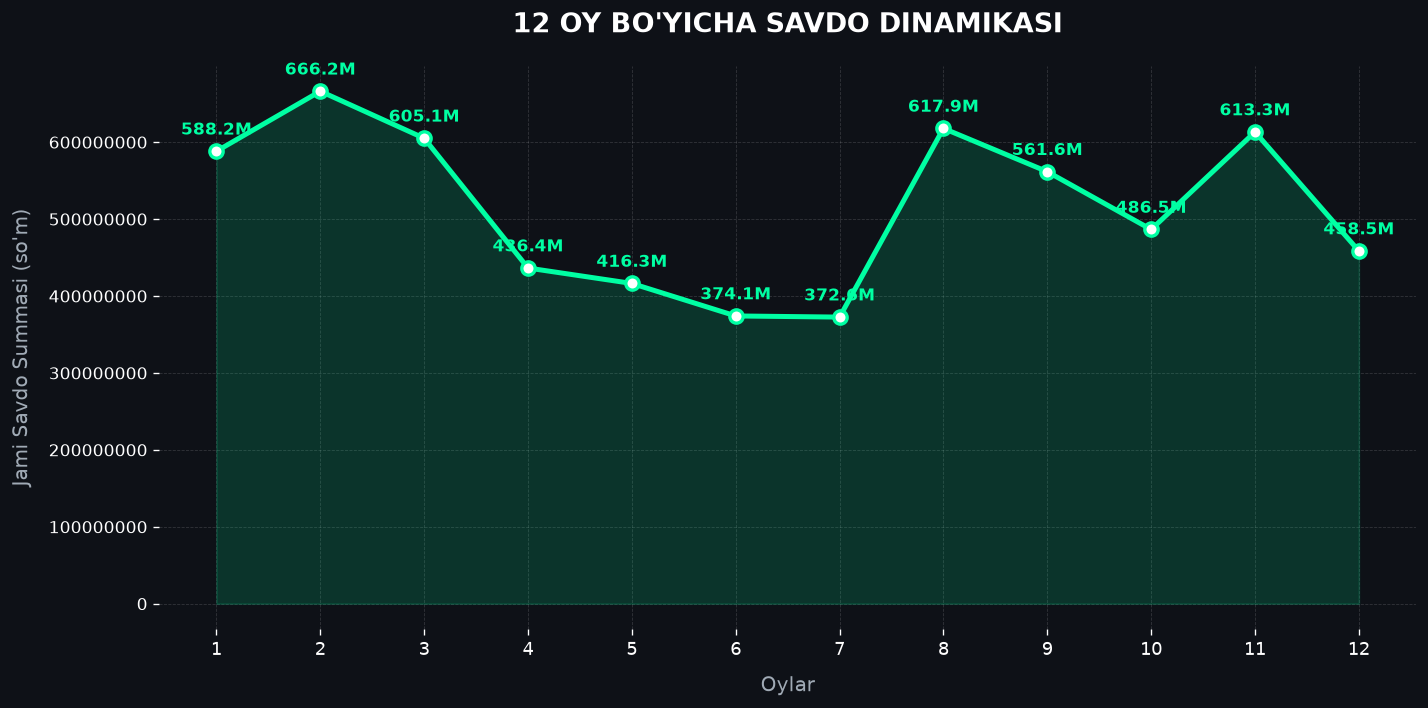

In [131]:
import matplotlib.pyplot as plt
import seaborn as sns


oylik_savdo = df.groupby('oy')['Jami_summa'].sum().reset_index()


plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12, 6), dpi=120)
fig.patch.set_facecolor('#0E1117')
ax.set_facecolor('#0E1117')


ax.plot(
    oylik_savdo['oy'],
    oylik_savdo['Jami_summa'],
    color='#00FFA3',
    linewidth=3,
    marker='o',
    markersize=8,
    markerfacecolor='#FFFFFF',
    markeredgecolor='#00FFA3',
    markeredgewidth=2,
    zorder=3,
)


ax.fill_between(
    oylik_savdo['oy'],
    oylik_savdo['Jami_summa'],
    color='#00FFA3',
    alpha=0.15,
    zorder=2,
)


for x, y in zip(oylik_savdo['oy'], oylik_savdo['Jami_summa']):

    label = f"{y / 1e6:.1f}M"
    ax.annotate(
        label,
        (x, y),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontsize=10,
        fontweight='bold',
        color='#00FFA3',
    )


plt.title(
    "12 OY BO'YICHA SAVDO DINAMIKASI",
    fontsize=16,
    fontweight='bold',
    color='white',
    pad=20,
)
plt.xlabel('Oylar', fontsize=12, color='#A0AAB5', labelpad=10)
plt.ylabel(
    'Jami Savdo Summasi (so\'m)', fontsize=12, color='#A0AAB5', labelpad=10
)


plt.xticks(oylik_savdo['oy'], color='white', fontsize=11)
plt.yticks(color='white', fontsize=10)
ax.ticklabel_format(style='plain', axis='y')  # Ilmiy (E+) formatni o'chirish
ax.grid(True, linestyle='--', alpha=0.15, color='white', zorder=1)


for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig(
    '01_chiziqli_grafik.png',
    dpi=300,
    bbox_inches='tight',
    facecolor=fig.get_facecolor(),
)

plt.show()

✅ 02_ustunli_diagramma.png saqlandi!


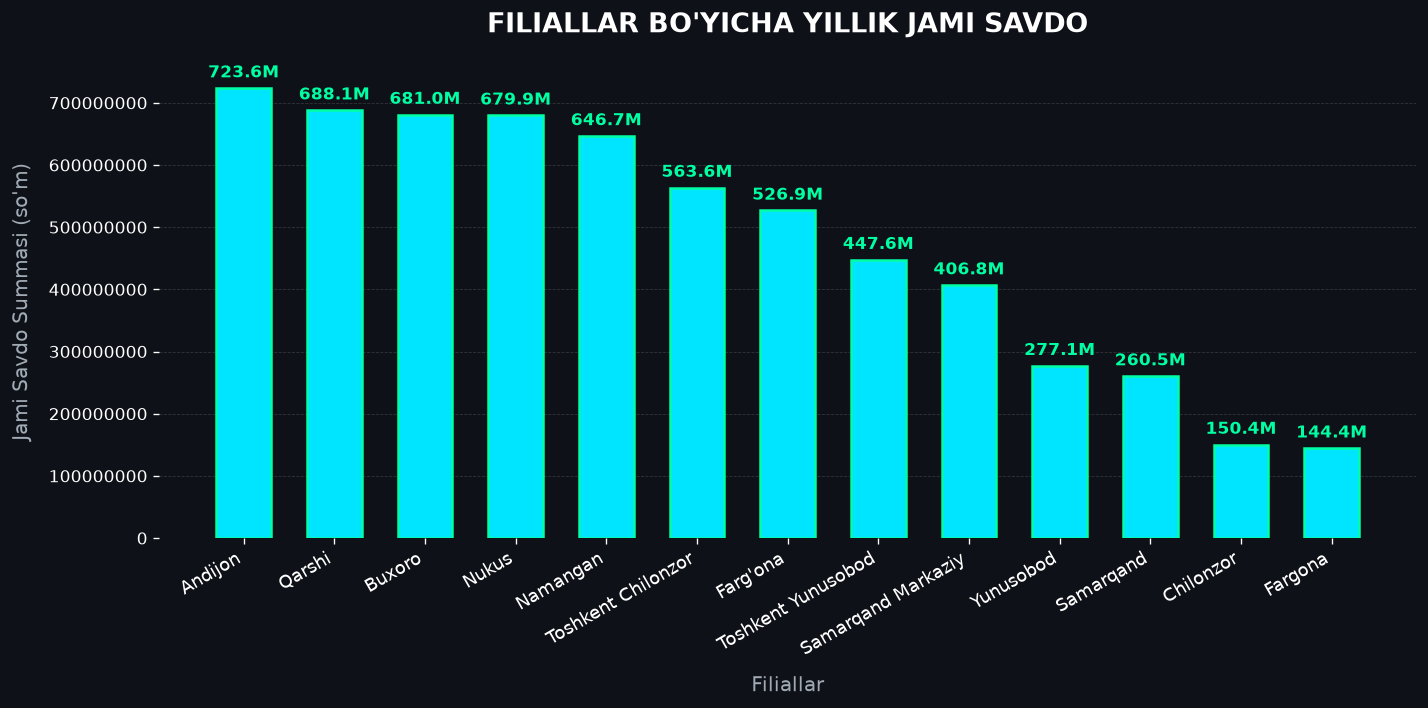

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns


filial_savdo = (
    df.groupby('Filial')['Jami_summa']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)


plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12, 6), dpi=120)
fig.patch.set_facecolor('#0E1117')
ax.set_facecolor('#0E1117')


bars = ax.bar(
    filial_savdo['Filial'],
    filial_savdo['Jami_summa'],
    color='#00E5FF',
    edgecolor='#00FFA3',
    linewidth=1.5,
    width=0.6,
    zorder=3,
)


for bar in bars:
    yval = bar.get_height()

    label = f"{yval / 1e6:.1f}M"
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        yval + (filial_savdo['Jami_summa'].max() * 0.015),
        label,
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#00FFA3',
    )


plt.title(
    "FILIALLAR BO'YICHA YILLIK JAMI SAVDO",
    fontsize=16,
    fontweight='bold',
    color='white',
    pad=20,
)
plt.xlabel('Filiallar', fontsize=12, color='#A0AAB5', labelpad=10)
plt.ylabel(
    'Jami Savdo Summasi (so\'m)', fontsize=12, color='#A0AAB5', labelpad=10
)


plt.xticks(rotation=30, ha='right', color='white', fontsize=11)
plt.yticks(color='white', fontsize=10)
ax.ticklabel_format(style='plain', axis='y')  # Oddiy raqamlar formati

ax.grid(True, linestyle='--', alpha=0.15, color='white', axis='y', zorder=1)

# Chegaralarni tozalash (Zamonaviy minimalizm)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig(
    '02_ustunli_diagramma.png',
    dpi=300,
    bbox_inches='tight',
    facecolor=fig.get_facecolor(),
)
print('✅ 02_ustunli_diagramma.png saqlandi!')
plt.show()

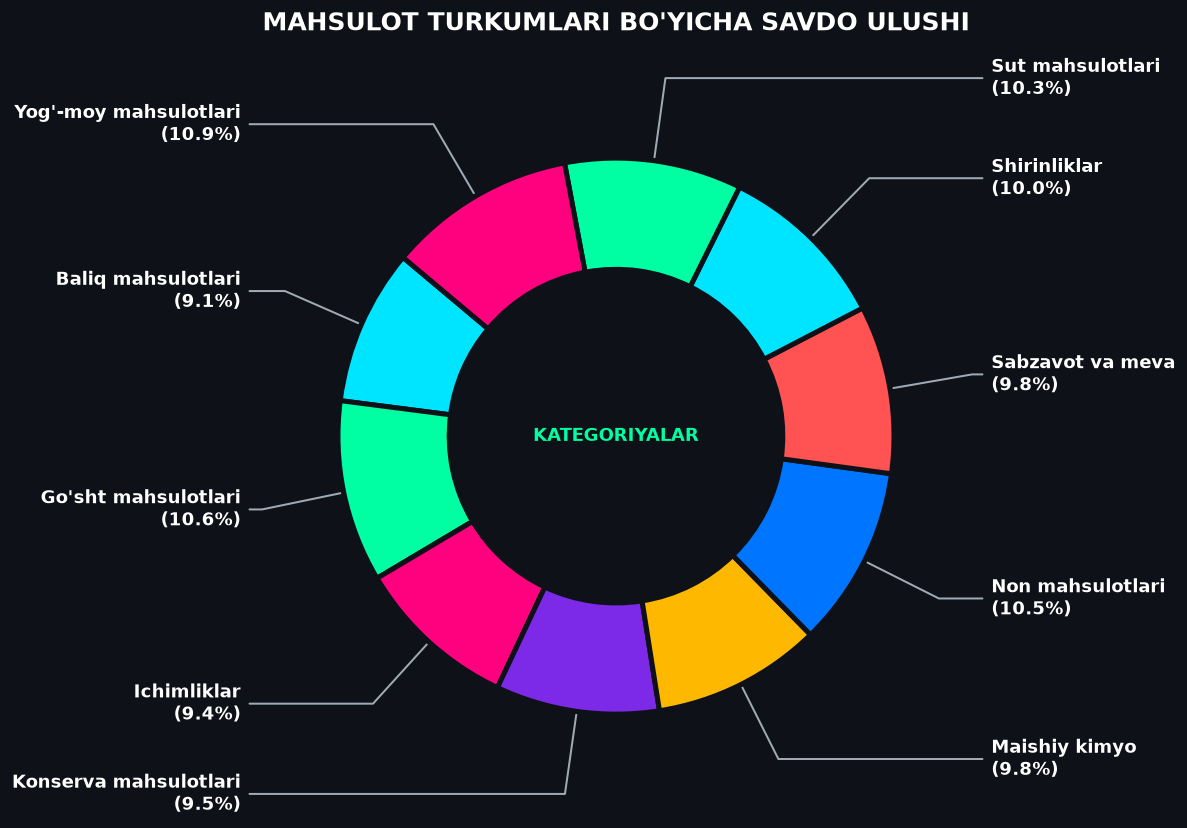

In [134]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Data tayyorlash
kategoriya_savdo = df.groupby('Mahsulot_turkumi')['Jami_summa'].sum().reset_index()

data = kategoriya_savdo['Jami_summa']
labels = kategoriya_savdo['Mahsulot_turkumi']

# 2. Grafik uslubi va fon rangi (Dark Mode)
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 7), dpi=120)
fig.patch.set_facecolor('#0E1117')
ax.set_facecolor('#0E1117')

# 3. Yorqin va zamonaviy neon ranglar
colors = [
    '#00E5FF',
    '#00FFA3',
    '#FF007F',
    '#7D2AE8',
    '#FFB800',
    '#0075FF',
    '#FF5252',
]

# 4. Donut chart chizish (hech qanday ichki matnlarsiz)
wedges, _ = ax.pie(
    data,
    colors=colors[: len(data)],
    startangle=140,
    wedgeprops=dict(width=0.4, edgecolor='#0E1117', linewidth=3),
)

# 5. HAR BIR YOZUVNI O'Z BO'LAGIGA CHIZIQ (IP) BILAN BOG'LASH
bbox_props = dict(boxstyle='square,pad=0.3', fc='#0E1117', ec='none', lw=0.72)
kw = dict(
    arrowprops=dict(arrowstyle='-', color='#A0AAB5', lw=1.2),
    bbox=bbox_props,
    zorder=0,
    va='center',
)

for i, p in enumerate(wedges):
    # Bo'lakning markaziy burchagini hisoblash
    ang = (p.theta2 - p.theta1) / 2.0 + p.theta1
    y = np.sin(np.deg2rad(ang))
    x = np.cos(np.deg2rad(ang))


    horizontalalignment = {-1: 'right', 1: 'left'}[int(np.sign(x))]
    connectionstyle = f'angle,angleA=0,angleB={ang}'
    kw['arrowprops']['connectionstyle'] = connectionstyle


    percentage = f'{(data[i] / sum(data)) * 100:.1f}%'
    text_label = f'{labels[i]}\n({percentage})'


    ax.annotate(
        text_label,
        xy=(x, y),
        xytext=(1.35 * np.sign(x), 1.3 * y),
        horizontalalignment=horizontalalignment,
        color='white',
        fontsize=11,
        fontweight='bold',
        **kw,
    )


plt.title(
    "MAHSULOT TURKUMLARI BO'YICHA SAVDO ULUSHI",
    fontsize=15,
    fontweight='bold',
    color='white',
    pad=35,
)

ax.text(
    0,
    0,
    'KATEGORIYALAR',
    ha='center',
    va='center',
    fontsize=11,
    fontweight='bold',
    color='#00FFA3',
)

plt.tight_layout()
plt.savefig('03_mahsulot_ulushi.png', dpi=300, bbox_inches='tight')
plt.show()


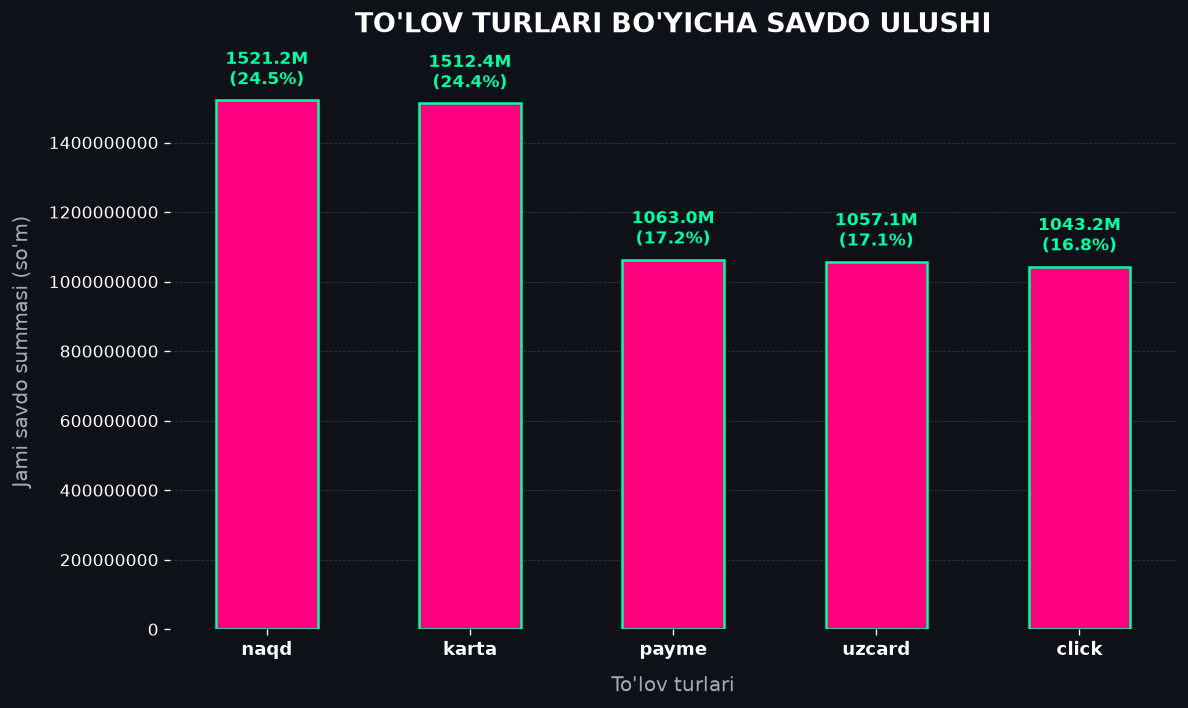

In [135]:
import os
import matplotlib.pyplot as plt
import seaborn as sns


tolov_savdo = (
    df.groupby('Tolov_turi')['Jami_summa']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)


jami_barcha_savdo = tolov_savdo['Jami_summa'].sum()


plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 6), dpi=120)
fig.patch.set_facecolor('#0E1117')
ax.set_facecolor('#0E1117')


bars = ax.bar(
    tolov_savdo['Tolov_turi'],
    tolov_savdo['Jami_summa'],
    color='#FF007F',
    edgecolor='#00FFA3',
    linewidth=1.5,
    width=0.5,
    zorder=3,
)

for bar in bars:
    yval = bar.get_height()
    percentage = (yval / jami_barcha_savdo) * 100


    label = f'{yval / 1e6:.1f}M\n({percentage:.1f}%)'

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        yval + (tolov_savdo['Jami_summa'].max() * 0.02),
        label,
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#00FFA3',
    )


plt.title(
    "TO'LOV TURLARI BO'YICHA SAVDO ULUSHI",
    fontsize=16,
    fontweight='bold',
    color='white',
    pad=25,
)
plt.xlabel("To'lov turlari", fontsize=12, color='#A0AAB5', labelpad=10)
plt.ylabel(
    'Jami savdo summasi (so\'m)', fontsize=12, color='#A0AAB5', labelpad=10
)

plt.xticks(color='white', fontsize=11, fontweight='bold')
plt.yticks(color='white', fontsize=10)
ax.ticklabel_format(style='plain', axis='y')


ax.grid(True, linestyle='--', alpha=0.15, color='white', axis='y', zorder=1)


for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()

plt.savefig(
    '04_tolov_turlari_ulushi.png',
    dpi=300,
    bbox_inches='tight',
    facecolor=fig.get_facecolor(),
)

plt.show()

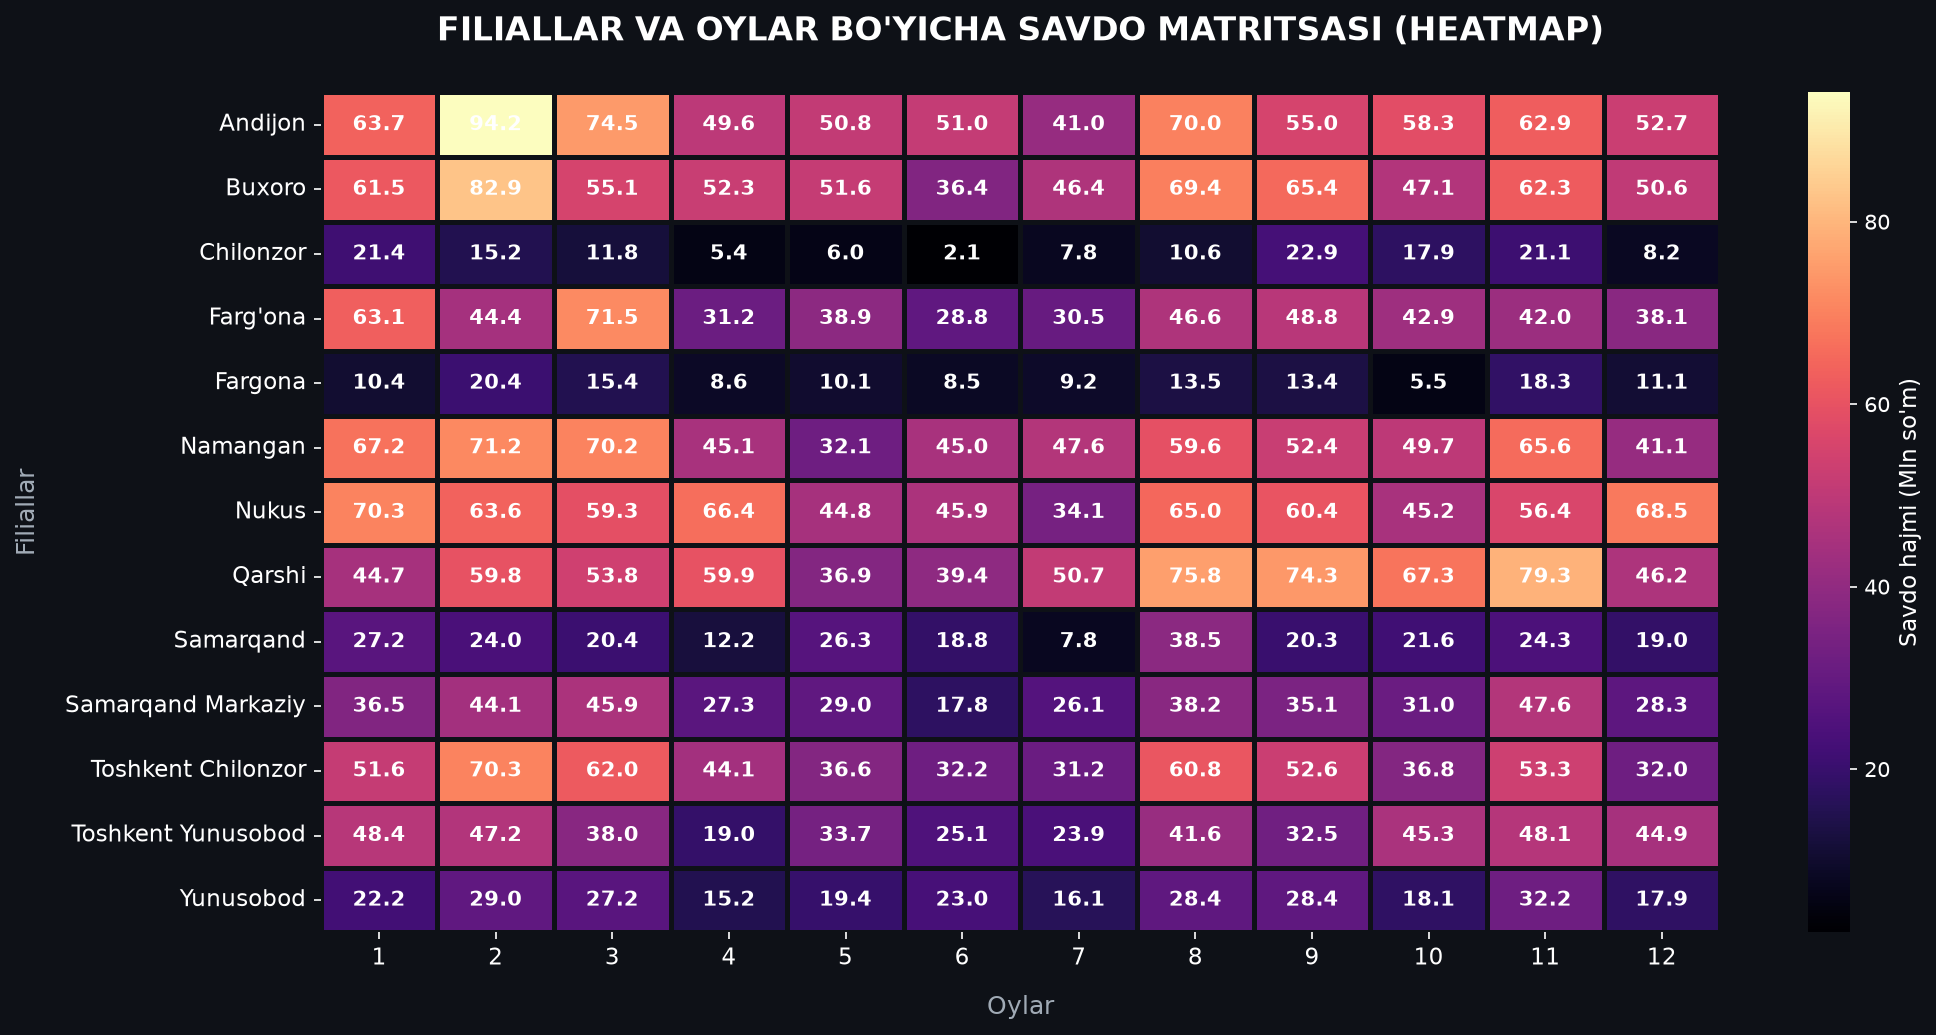

In [137]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


pivot_df = df.pivot_table(
    index='Filial', columns='oy', values='Jami_summa', aggfunc='sum'
).fillna(0)


pivot_df = pivot_df.reindex(columns=sorted(pivot_df.columns))

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(14, 7), dpi=150)  # Yuqori sifat
fig.patch.set_facecolor('#0E1117')
ax.set_facecolor('#0E1117')


sns.heatmap(
    pivot_df / 1e6,
    annot=True,
    fmt='.1f',  #
    cmap='magma',
    linewidths=1.5,
    linecolor='#0E1117',
    cbar_kws={'label': "Savdo hajmi (Mln so'm)"},
    ax=ax,
    annot_kws={'size': 10, 'weight': 'bold', 'color': 'white'},
)


plt.title(
    'FILIALLAR VA OYLAR BO\'YICHA SAVDO MATRITSASI (HEATMAP)',
    fontsize=16,
    fontweight='bold',
    color='white',
    pad=25,
)
plt.xlabel('Oylar', fontsize=12, color='#A0AAB5', labelpad=12)
plt.ylabel('Filiallar', fontsize=12, color='#A0AAB5', labelpad=12)


plt.xticks(color='white', fontsize=11)
plt.yticks(color='white', fontsize=11, rotation=0)

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_color('white')
cbar.ax.yaxis.label.set_size(11)
cbar.ax.tick_params(labelsize=10, labelcolor='white')

plt.tight_layout()


plt.savefig(
    '05_filial_oy_heatmap.png',
    dpi=300,
    bbox_inches='tight',
    facecolor=fig.get_facecolor(),
)


plt.show()

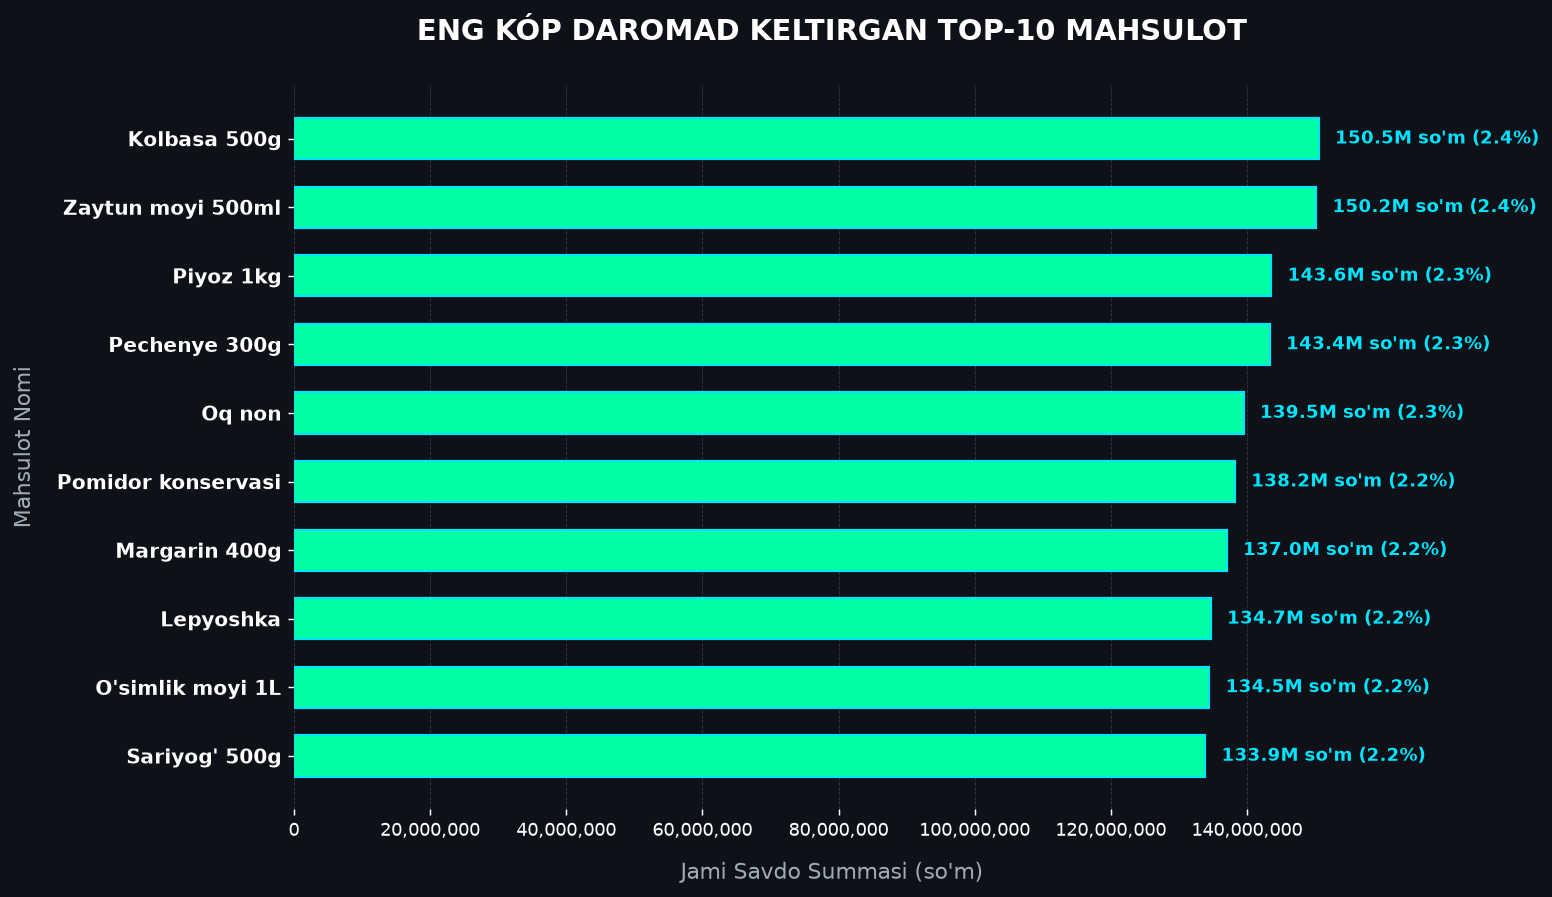

In [138]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

top_mahsulotlar = (
    df.groupby('Mahsulot_nomi')['Jami_summa']
    .sum()
    .sort_values(ascending=True)
    .tail(10)
    .reset_index()
)


jami_savdo = df['Jami_summa'].sum()

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12, 7), dpi=130)
fig.patch.set_facecolor('#0E1117')
ax.set_facecolor('#0E1117')


bars = ax.barh(
    top_mahsulotlar['Mahsulot_nomi'],
    top_mahsulotlar['Jami_summa'],
    color='#00FFA3',  # Neon yashil
    edgecolor='#00E5FF',  # Neon moviy chegara
    linewidth=1.2,
    height=0.6,
    zorder=3,
)


for bar in bars:
    xval = bar.get_width()
    percentage = (xval / jami_savdo) * 100


    label = f' {xval / 1e6:.1f}M so\'m ({percentage:.1f}%)'

    ax.text(
        xval + (top_mahsulotlar['Jami_summa'].max() * 0.01),
        bar.get_y() + bar.get_height() / 2,
        label,
        ha='left',
        va='center',
        fontsize=10,
        fontweight='bold',
        color='#00E5FF',
    )


plt.title(
    "ENG KÓP DAROMAD KELTIRGAN TOP-10 MAHSULOT",
    fontsize=16,
    fontweight='bold',
    color='white',
    pad=25,
)
plt.xlabel(
    "Jami Savdo Summasi (so'm)", fontsize=12, color='#A0AAB5', labelpad=12
)
plt.ylabel('Mahsulot Nomi', fontsize=12, color='#A0AAB5', labelpad=12)

plt.xticks(color='white', fontsize=10)
plt.yticks(color='white', fontsize=11, fontweight='bold')
ax.xaxis.set_major_formatter(
    '{x:,.0f}'
)

ax.grid(True, linestyle='--', alpha=0.15, color='white', axis='x', zorder=1)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()


plt.savefig(
    '06_top_10_mahsulotlar.png',
    dpi=300,
    bbox_inches='tight',
    facecolor=fig.get_facecolor(),
)

plt.show()

In [ ]:
df.to_excel("ready_dataset.xlsx")